In [1]:
#numpy
import numpy as np
from numpy.linalg import inv ; from numpy.linalg import cholesky 
from numpy.random import rand
from numpy import longdouble

import matplotlib.pyplot as plt
import pandas as pd 
#import numba
#from numba import njit

#sklearn
import sklearn
from sklearn.datasets import make_spd_matrix
from sklearn.linear_model import Ridge

#scipy
import scipy
import scipy.linalg as la
from scipy import special
from scipy.linalg import sqrtm
from scipy.linalg import eigh
from scipy.special import erfc, erf

#torch
import torch
from torchvision import datasets
from torchvision.datasets import MNIST
from torchvision import transforms

#sympay
import sympy
from sympy.stats import Gumbel


from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import GridSearchCV

from tqdm import tqdm

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
def preprocess_data(dataset):
    global mu
    '''
    Take the pyTorch MNIST dataset, flatten the 28x28 images in a 784 dimensional
    array, center the data and divide by the global standard deviation.
    Then select only odd and even digits and assign them {-1,+1} labels.
    '''
    n, d_x, d_y = dataset.data.shape
    d = d_x * d_y
    X = torch.clone(dataset.data).view(n,-1).float()
    y = torch.clone(dataset.targets).view(n,).float()
    data, labels = [], []
    # Extract digits and create labels
    for k,label in enumerate(y):
        if label in [5,7,8,9,6]:
            data.append(X[k].numpy())
            labels.append(1)
        if label in [0,1,2,3,4]:
            data.append(X[k].numpy())
            labels.append(-1)
        
            
    data = np.array(data)
    mu=data.mean(axis=0)
    data -= mu
    data /= 300
    return np.array(data), np.array(labels)

In [12]:
# Load MNIST 
mnist_trainset= datasets.MNIST(root='data', train=True, 
                               download=True, transform=None)
mnist_testset= datasets.MNIST(root='data', train=False, 
                               download=True, transform=None)
# Pre-process
X_train, y_train = preprocess_data(mnist_trainset)
X_test, y_test = preprocess_data(mnist_testset)
n, p = X_train.shape

In [22]:
X=np.vstack((X_train, X_test))
y=np.hstack((y_train, y_test))

permutation = np.random.permutation(len(y))

X= X[permutation]
y= y[permutation]

### Partition the datasets

In [23]:
#Partition into the different datasets
XNN=X[:3000]; yNN=y[:3000]
Xbeta=X[3000:53000]; ybeta=y[3000:53000]
Xtrain=X[53000:53500];ytrain=y[53000:53500]
Xtest=X[53500:];ytest=y[53500:]

### Training the neural network feature map

In [24]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#Create neural network
class MLP(nn.Module):
    def __init__(self, d):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(d, 1000)
        self.bn1 = nn.BatchNorm1d(1000)
        self.fc2 = nn.Linear(1000, 1000)
        self.bn2 = nn.BatchNorm1d(1000)
        self.bn3 = nn.BatchNorm1d(1000)
        self.fc3 = nn.Linear(1000, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.bn3(self.relu(self.bn2(self.fc2(x))))
        x = self.fc3(x)
        return x



n,d= Xtrain.shape[0], Xtrain.shape[1]
X = torch.from_numpy(Xtrain)
y = (torch.from_numpy(ytrain)+1)/2  

model = MLP(d)


y = y.float().unsqueeze(1)
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=n, shuffle=True)
criterion = nn.BCEWithLogitsLoss()  
optimizer = optim.Adam(model.parameters())

# Training 
num_epochs = 10
for epoch in range(num_epochs):
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')

Epoch 1/10, Loss: 0.7840
Epoch 2/10, Loss: 0.5460
Epoch 3/10, Loss: 0.2311
Epoch 4/10, Loss: 0.1196
Epoch 5/10, Loss: 0.0844
Epoch 6/10, Loss: 0.0566
Epoch 7/10, Loss: 0.0368
Epoch 8/10, Loss: 0.0262
Epoch 9/10, Loss: 0.0189
Epoch 10/10, Loss: 0.0134


In [25]:
Xbeta = model.bn3(model.relu(model.bn2(model.fc2(model.relu(model.bn1(model.fc1(torch.from_numpy(Xbeta)))))))).detach().numpy()
Xtrain=model.bn3(model.relu(model.bn2(model.fc2(model.relu(model.bn1(model.fc1(torch.from_numpy(Xtrain)))))))).detach().numpy()
Xtest=model.bn3(model.relu(model.bn2(model.fc2(model.relu(model.bn1(model.fc1(torch.from_numpy(Xtest)))))))).detach().numpy()

### Estimating $\beta$

In [26]:
model = LR(penalty='l2', random_state=42, fit_intercept=False, C=100)
model.fit(Xbeta, ybeta)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [28]:
β=(model.coef_).flatten()

### Estimating $\hat{w}$

In [29]:
model = LR(penalty='l2', random_state=42, fit_intercept=False, C=10)
base_error=np.mean((model.fit(Xtrain, ytrain)).predict(Xtest)!=ytest)

In [30]:
w=(model.coef_).flatten()

In [34]:
ex=w/np.linalg.norm(w)
bperp=β-np.outer(ex,ex)@β
ey=bperp/np.linalg.norm(bperp)

### Computing influences

In [36]:
def train_with(X,Y, x,y):
    Xtot=np.vstack((X,x.reshape(1, -1)))
    ytot=np.hstack((Y, np.array([y])))
    model = LR(penalty='l2', random_state=42, fit_intercept=False, C=10)
    diff=np.mean((model.fit(Xtot, ytot)).predict(Xtest)!=ytest)-base_error
    return diff*Xtrain.shape[0]

In [37]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)
for i in tqdm(range(X.shape[0])):
    for j in range(X.shape[1]):        
        x=X[i,j]*ex+Y[i,j]*ey
        ypred=np.sign(β@x)
        Z[i,j] = train_with(Xtrain,ytrain, x,ypred)


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [19:05<00:00, 11.45s/it]


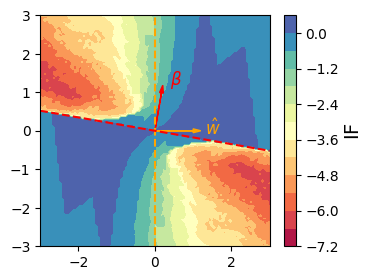

In [180]:
plt.figure(figsize=(3.7, 3))
contour = plt.contourf(X, Y, Z, levels=12, cmap='Spectral')
cbar=plt.colorbar(contour, label=r'$\mathrm{IF}$')
cbar.set_label(r'$\mathrm{IF}$', fontdict={'fontsize': 14})

plt.vlines(0,-3,3, ls="--", color="orange")
xs=np.linspace(-3,3,20)
plt.plot(xs, - β@ex/( β@ey)*xs, ls="--", c="r")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.arrow(0, 0, β@ex/np.sqrt((β@ex)**2+(β@ey)**2) , β@ey/np.sqrt((β@ex)**2+(β@ey)**2), head_width=0.1, head_length=0.2, fc='r', ec='r')
plt.arrow(0, 0, w@ex/np.sqrt((w@ex)**2+(w@ey)**2) , w@ey/np.sqrt((w@ex)**2+(w@ey)**2), head_width=0.1, head_length=0.2, fc='orange', ec='orange')
plt.text(1.3, -.1, r'$\hat{w}$', fontsize=12, color='orange')
plt.text(.4, 1.2, r'$\beta$', fontsize=12, color='red')
